In [2]:
# Import libraries required for exploratory data analysis.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [4]:
# Define the path to the cleaned historical route-level dataset.
DATA_PATH = Path(
    "../data/processed/bitre_otp_historical_route_level.csv"
)

# Load the dataset and parse the month column as dates.
# Store the source worksheet identifier as text.
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["month"],
    dtype={
        "source_sheet": "string",
    },
    low_memory=False,
)

# Display the dataset shape.
print(f"Dataset shape: {df.shape}")

# Display the first five observations.
df.head()

Dataset shape: (69188, 24)


,route,departing_port,arriving_port,airline,month,sectors_scheduled,sectors_flown,cancellations,departures_on_time,arrivals_on_time,...,cancellations_pct,source_sheet,is_all_airlines,is_all_ports,is_route_level,scheduled_sector_valid,departure_classification_valid,arrival_classification_valid,no_flown_sectors,missing_on_time_percentage
0,Adelaide-Alice Springs,Adelaide,Alice Springs,Qantas,2010-01-01,31.0,31.0,0.0,31.0,31.0,...,0.0,2010,False,False,True,True,True,True,False,False
1,Adelaide-Alice Springs,Adelaide,Alice Springs,Tigerair Australia,2010-01-01,13.0,13.0,0.0,11.0,11.0,...,0.0,2010,False,False,True,True,True,True,False,False
2,Adelaide-Brisbane,Adelaide,Brisbane,Jetstar,2010-01-01,30.0,30.0,0.0,22.0,23.0,...,0.0,2010,False,False,True,True,True,True,False,False
3,Adelaide-Brisbane,Adelaide,Brisbane,Qantas,2010-01-01,94.0,94.0,0.0,89.0,91.0,...,0.0,2010,False,False,True,True,True,True,False,False
4,Adelaide-Brisbane,Adelaide,Brisbane,Virgin Australia,2010-01-01,93.0,93.0,0.0,87.0,87.0,...,0.0,2010,False,False,True,True,True,True,False,False


In [5]:
# Inspect the structure of the route-level historical dataset.

# Display column names and data types.
print("Dataset information:")
print("--------------------")
df.info()

# Display the historical date range.
print("\nDate range:")
print("-----------")
print(f"Earliest month: {df['month'].min()}")
print(f"Latest month:   {df['month'].max()}")

# Count unique airlines, routes and airports.
print("\nDataset coverage:")
print("-----------------")
print(f"Unique airlines:           {df['airline'].nunique()}")
print(f"Unique routes:             {df['route'].nunique()}")
print(f"Unique departing airports: {df['departing_port'].nunique()}")
print(f"Unique arriving airports:  {df['arriving_port'].nunique()}")

# Display the airlines represented in the dataset.
print("\nAirlines:")
print("---------")

for airline in sorted(df["airline"].unique()):
    print(airline)

# Count missing values in each column.
print("\nMissing values:")
print("---------------")

missing_values = df.isna().sum()

print(
    missing_values[
        missing_values > 0
    ]
)

Dataset information:
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 69188 entries, 0 to 69187
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   route                           69188 non-null  str           
 1   departing_port                  69188 non-null  str           
 2   arriving_port                   69188 non-null  str           
 3   airline                         69188 non-null  str           
 4   month                           69188 non-null  datetime64[us]
 5   sectors_scheduled               69188 non-null  float64       
 6   sectors_flown                   69188 non-null  float64       
 7   cancellations                   69188 non-null  float64       
 8   departures_on_time              69188 non-null  float64       
 9   arrivals_on_time                69188 non-null  float64       
 10  departures_delayed              69188 n

In [6]:
# Investigate rows with missing cancellation percentages.

# Select observations where the cancellation percentage is missing.
missing_cancellation_pct = df[
    df["cancellations_pct"].isna()
].copy()

print("Missing cancellation percentage rows:")
print("-------------------------------------")
print(f"Total rows: {len(missing_cancellation_pct)}")

# Check whether missing cancellation percentages occur
# when no flights were scheduled.
print(
    "All have zero scheduled sectors: "
    f"{(missing_cancellation_pct['sectors_scheduled'] == 0).all()}"
)

# Display the relevant columns for inspection.
missing_cancellation_pct[
    [
        "route",
        "airline",
        "month",
        "sectors_scheduled",
        "sectors_flown",
        "cancellations",
        "cancellations_pct",
    ]
]

Missing cancellation percentage rows:
-------------------------------------
Total rows: 26
All have zero scheduled sectors: True


,route,airline,month,sectors_scheduled,sectors_flown,cancellations,cancellations_pct
5498,Adelaide-Melbourne,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5507,Adelaide-Sydney,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5535,Brisbane-Melbourne,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5549,Brisbane-Sydney,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5563,Cairns-Melbourne,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5577,Canberra-Melbourne,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5596,Gold Coast-Melbourne,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5599,Gold Coast-Sydney,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5607,Hobart-Melbourne,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN
5630,Melbourne-Adelaide,Tigerair Australia,2011-07-01,0.0,0.0,0.0,NaN


In [7]:
# Aggregate route-level observations by month.
monthly_performance = (
    df.groupby("month", as_index=False)
    .agg(
        sectors_scheduled=("sectors_scheduled", "sum"),
        sectors_flown=("sectors_flown", "sum"),
        cancellations=("cancellations", "sum"),
        departures_on_time=("departures_on_time", "sum"),
        departures_delayed=("departures_delayed", "sum"),
    )
)

# Calculate monthly departure performance using flight counts
# rather than averaging route-level percentages.
monthly_performance["on_time_departure_pct"] = (
    monthly_performance["departures_on_time"]
    / monthly_performance["sectors_flown"]
    * 100
)

monthly_performance["departure_delay_pct"] = (
    monthly_performance["departures_delayed"]
    / monthly_performance["sectors_flown"]
    * 100
)

monthly_performance["cancellation_pct"] = (
    monthly_performance["cancellations"]
    / monthly_performance["sectors_scheduled"]
    * 100
)

# Display the first five monthly observations.
monthly_performance.head()

,month,sectors_scheduled,sectors_flown,cancellations,departures_on_time,departures_delayed,on_time_departure_pct,departure_delay_pct,cancellation_pct
0,2010-01-01,29704.0,29426.0,278.0,26060.0,3366.0,88.561136,11.438864,0.935901
1,2010-02-01,28236.0,27935.0,301.0,23769.0,4166.0,85.086809,14.913191,1.066015
2,2010-03-01,32208.0,31648.0,560.0,26926.0,4722.0,85.079626,14.920374,1.738698
3,2010-04-01,32070.0,31746.0,324.0,27632.0,4114.0,87.040887,12.959113,1.010290
4,2010-05-01,33110.0,32798.0,312.0,28639.0,4159.0,87.319349,12.680651,0.942314


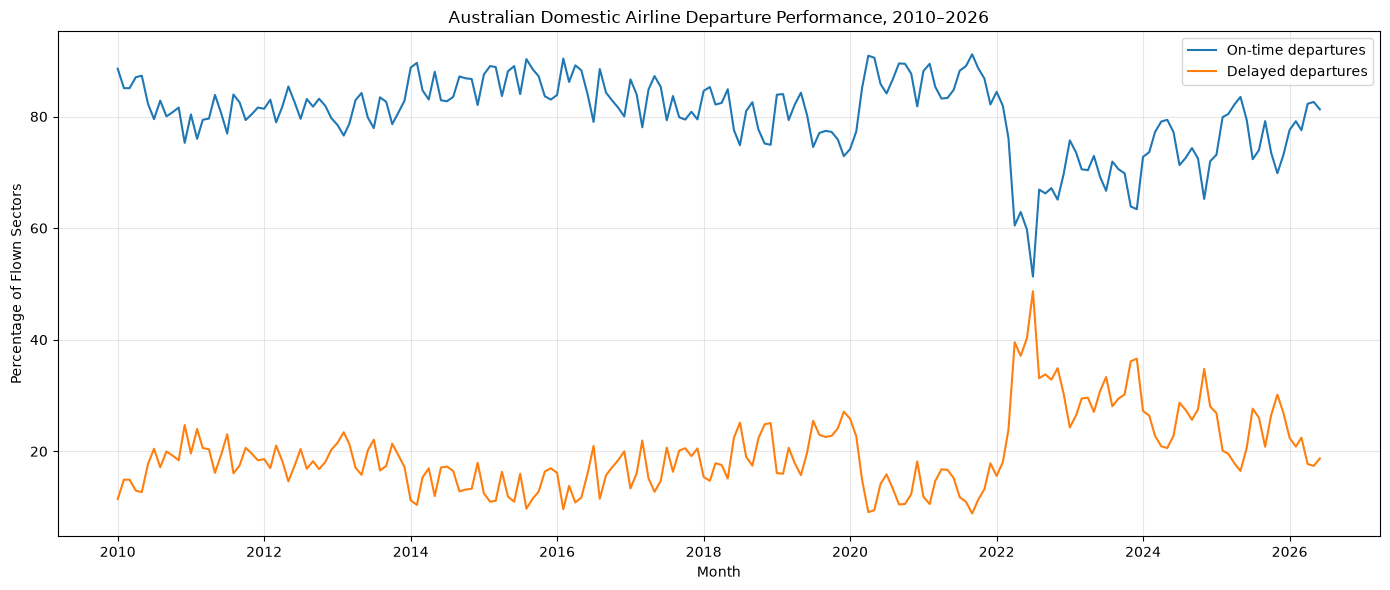

In [8]:
# Plot monthly departure performance across the historical period.
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["month"],
    monthly_performance["on_time_departure_pct"],
    label="On-time departures",
)

plt.plot(
    monthly_performance["month"],
    monthly_performance["departure_delay_pct"],
    label="Delayed departures",
)

plt.title(
    "Australian Domestic Airline Departure Performance, 2010–2026"
)
plt.xlabel("Month")
plt.ylabel("Percentage of Flown Sectors")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Identify the months with the highest departure delay percentages.

worst_delay_months = (
    monthly_performance[
        [
            "month",
            "sectors_flown",
            "on_time_departure_pct",
            "departure_delay_pct",
            "cancellation_pct",
        ]
    ]
    .sort_values(
        "departure_delay_pct",
        ascending=False,
    )
    .head(10)
)

worst_delay_months

,month,sectors_flown,on_time_departure_pct,departure_delay_pct,cancellation_pct
150,2022-07-01,32450.0,51.309707,48.690293,7.365116
149,2022-06-01,32753.0,59.738039,40.261961,6.644054
147,2022-04-01,33597.0,60.460755,39.539245,4.562111
148,2022-05-01,34003.0,62.888569,37.111431,6.283935
167,2023-12-01,34260.0,63.391710,36.608290,5.083807
166,2023-11-01,34383.0,63.868772,36.131228,3.955418
154,2022-11-01,32795.0,65.101387,34.898613,4.911711
178,2024-11-01,33060.0,65.235935,34.764065,2.610028
152,2022-09-01,31865.0,66.219991,33.780009,3.573806
162,2023-07-01,35447.0,66.682653,33.317347,4.285251


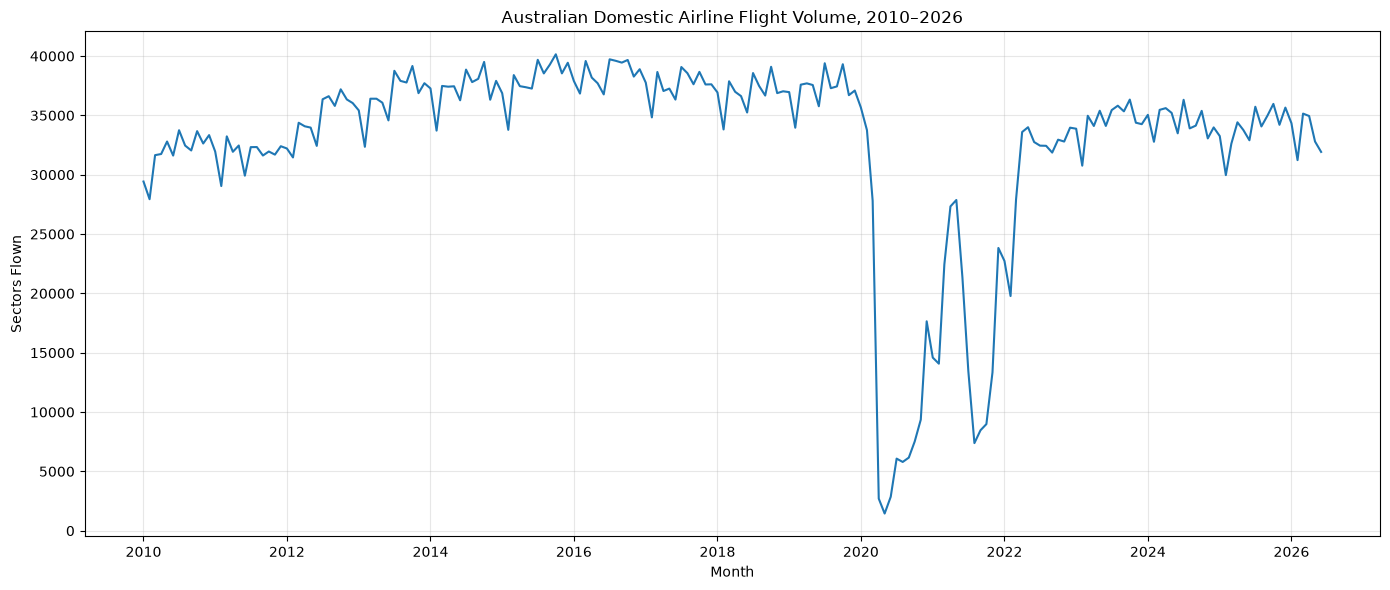

In [10]:
# Plot monthly domestic flight volume across the historical period.
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["month"],
    monthly_performance["sectors_flown"],
)

plt.title(
    "Australian Domestic Airline Flight Volume, 2010–2026"
)
plt.xlabel("Month")
plt.ylabel("Sectors Flown")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# Create a year column for annual trend analysis.
monthly_performance["year"] = (
    monthly_performance["month"].dt.year
)

# Aggregate monthly flight counts into annual totals.
annual_performance = (
    monthly_performance
    .groupby("year", as_index=False)
    .agg(
        sectors_scheduled=("sectors_scheduled", "sum"),
        sectors_flown=("sectors_flown", "sum"),
        cancellations=("cancellations", "sum"),
        departures_on_time=("departures_on_time", "sum"),
        departures_delayed=("departures_delayed", "sum"),
    )
)

# Calculate annual performance rates using underlying
# flight counts rather than averaging monthly percentages.
annual_performance["on_time_departure_pct"] = (
    annual_performance["departures_on_time"]
    / annual_performance["sectors_flown"]
    * 100
)

annual_performance["departure_delay_pct"] = (
    annual_performance["departures_delayed"]
    / annual_performance["sectors_flown"]
    * 100
)

annual_performance["cancellation_pct"] = (
    annual_performance["cancellations"]
    / annual_performance["sectors_scheduled"]
    * 100
)

# Display the annual performance summary.
annual_performance

,year,sectors_scheduled,sectors_flown,cancellations,departures_on_time,departures_delayed,on_time_departure_pct,departure_delay_pct,cancellation_pct
0,2010,387694.0,383053.0,4641.0,317331.000000,65722.000000,82.842583,17.157417,1.197078
1,2011,388654.0,380865.0,7789.0,306311.971975,74553.028025,80.425340,19.574660,2.004096
2,2012,423460.0,416875.0,6585.0,341222.000000,75653.000000,81.852354,18.147646,1.555047
3,2013,447887.0,439410.0,8477.0,354231.000000,85179.000000,80.615143,19.384857,1.892665
4,2014,455379.0,448087.0,7292.0,383004.000000,65083.000000,85.475365,14.524635,1.601304
5,2015,464797.0,456773.0,8024.0,396811.000000,59962.000000,86.872692,13.127308,1.726345
6,2016,471051.0,462579.0,8472.0,392333.000000,70246.000000,84.814270,15.185730,1.798531
7,2017,460235.0,451035.0,9200.0,371400.000000,79635.000000,82.343942,17.656058,1.998979
8,2018,452402.0,443193.0,9209.0,355449.000000,87744.000000,80.201853,19.798147,2.035579
9,2019,457279.0,446773.0,10506.0,353044.000000,93729.000000,79.020890,20.979110,2.297503


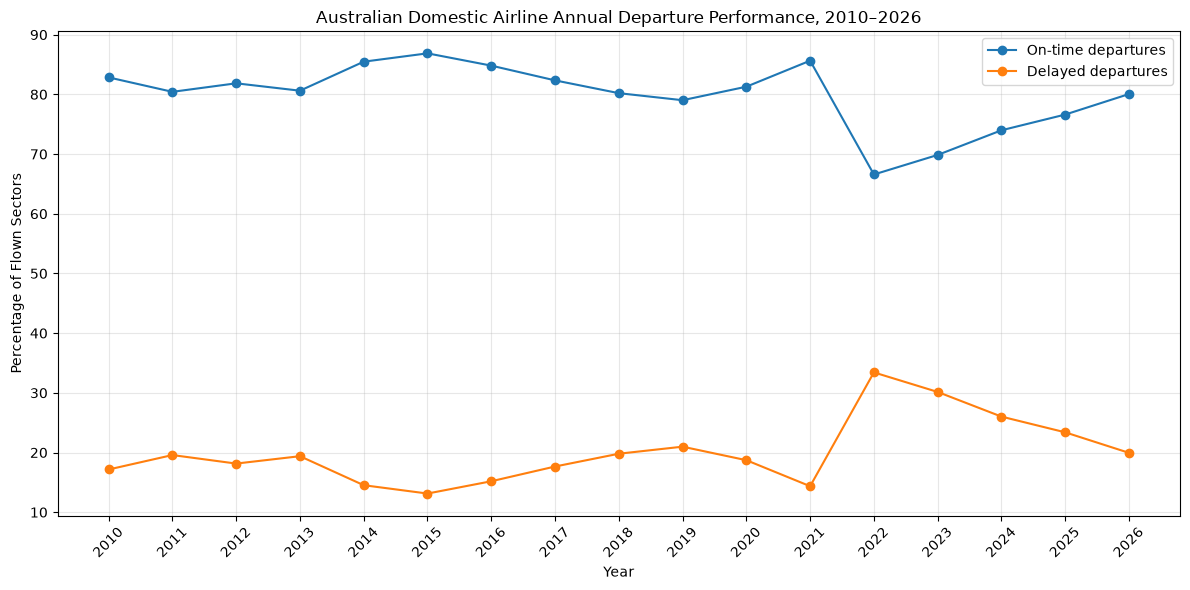

In [12]:
# Plot annual departure performance across the historical period.
plt.figure(figsize=(12, 6))

plt.plot(
    annual_performance["year"],
    annual_performance["on_time_departure_pct"],
    marker="o",
    label="On-time departures",
)

plt.plot(
    annual_performance["year"],
    annual_performance["departure_delay_pct"],
    marker="o",
    label="Delayed departures",
)

plt.title(
    "Australian Domestic Airline Annual Departure Performance, 2010–2026"
)
plt.xlabel("Year")
plt.ylabel("Percentage of Flown Sectors")
plt.xticks(
    annual_performance["year"],
    rotation=45,
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Aggregate flight performance by airline using underlying flight counts.
airline_performance = (
    df.groupby("airline", as_index=False)
    .agg(
        sectors_flown=("sectors_flown", "sum"),
        departures_on_time=("departures_on_time", "sum"),
        departures_delayed=("departures_delayed", "sum"),
        cancellations=("cancellations", "sum"),
        sectors_scheduled=("sectors_scheduled", "sum"),
    )
)

# Calculate airline-level performance rates.
airline_performance["on_time_departure_pct"] = (
    airline_performance["departures_on_time"]
    / airline_performance["sectors_flown"]
    * 100
)

airline_performance["departure_delay_pct"] = (
    airline_performance["departures_delayed"]
    / airline_performance["sectors_flown"]
    * 100
)

airline_performance["cancellation_pct"] = (
    airline_performance["cancellations"]
    / airline_performance["sectors_scheduled"]
    * 100
)

# Sort airlines from highest to lowest departure delay rate.
airline_performance = airline_performance.sort_values(
    "departure_delay_pct",
    ascending=False,
)

# Display the airline performance summary.
airline_performance


,airline,sectors_flown,departures_on_time,departures_delayed,cancellations,sectors_scheduled,on_time_departure_pct,departure_delay_pct,cancellation_pct
0,Bonza,344.0,1.680000e+02,176.000000,26.0,370.0,48.837209,51.162791,7.027027
1,Jetstar,1054823.0,7.734730e+05,281350.000000,37474.0,1092297.0,73.327279,26.672721,3.430752
7,Tigerair Australia,218786.0,1.655730e+05,53213.028025,4658.0,223444.0,75.678047,24.321953,2.084639
6,Skywest,7395.0,5.608000e+03,1787.000000,40.0,7435.0,75.835024,24.164976,0.537996
5,Rex Airlines,118541.0,9.178400e+04,26757.000000,3270.0,121811.0,77.428063,22.571937,2.684487
3,QantasLink,1214817.0,9.734260e+05,241391.000000,41451.0,1256268.0,80.129435,19.870565,3.299535
8,Virgin Australia,2005655.0,1.618620e+06,387035.000000,52889.0,2058544.0,80.702813,19.297187,2.569243
9,Virgin Australia - ATR/F100 Operations,20585.0,1.665100e+04,3934.000000,466.0,21051.0,80.888997,19.111003,2.213672
10,Virgin Australia Regional Airlines,111181.0,9.103600e+04,20145.000000,2485.0,113666.0,81.880897,18.119103,2.186230
2,Qantas,1550037.0,1.283296e+06,266741.000000,41740.0,1591777.0,82.791314,17.208686,2.622227


In [14]:
# Summarise airline coverage across the historical dataset.
airline_coverage = (
    df.groupby("airline", as_index=False)
    .agg(
        first_month=("month", "min"),
        last_month=("month", "max"),
        observations=("airline", "size"),
        sectors_flown=("sectors_flown", "sum"),
    )
)

# Calculate the number of distinct months represented
# for each airline.
airline_month_counts = (
    df.groupby("airline")["month"]
    .nunique()
    .rename("months_covered")
    .reset_index()
)

# Combine airline coverage information.
airline_coverage = airline_coverage.merge(
    airline_month_counts,
    on="airline",
    how="left",
)

# Sort airlines by total sectors flown.
airline_coverage = airline_coverage.sort_values(
    "sectors_flown",
    ascending=False,
)

airline_coverage

,airline,first_month,last_month,observations,sectors_flown,months_covered
8,Virgin Australia,2010-01-01,2026-06-01,20224,2005655.0,198
2,Qantas,2010-01-01,2026-06-01,11971,1550037.0,198
3,QantasLink,2010-01-01,2026-06-01,13303,1214817.0,198
1,Jetstar,2010-01-01,2026-06-01,13182,1054823.0,198
7,Tigerair Australia,2010-01-01,2020-02-01,3662,218786.0,122
4,Regional Express,2010-01-01,2021-06-01,2002,190697.0,138
5,Rex Airlines,2021-07-01,2026-06-01,1632,118541.0,60
10,Virgin Australia Regional Airlines,2013-05-01,2026-06-01,2676,111181.0,158
9,Virgin Australia - ATR/F100 Operations,2011-11-01,2013-04-01,272,20585.0,18
6,Skywest,2010-01-01,2013-04-01,234,7395.0,40


In [15]:
# Select airlines with complete coverage from 2010 to June 2026.
full_period_airlines = [
    "Virgin Australia",
    "Qantas",
    "QantasLink",
    "Jetstar",
]

# Keep performance results for the selected airlines.
comparable_airlines = airline_performance[
    airline_performance["airline"].isin(
        full_period_airlines
    )
].copy()

# Sort airlines from lowest to highest departure delay rate.
comparable_airlines = comparable_airlines.sort_values(
    "departure_delay_pct"
)

# Display the comparable airline results.
comparable_airlines[
    [
        "airline",
        "sectors_flown",
        "on_time_departure_pct",
        "departure_delay_pct",
        "cancellation_pct",
    ]
]

,airline,sectors_flown,on_time_departure_pct,departure_delay_pct,cancellation_pct
2,Qantas,1550037.0,82.791314,17.208686,2.622227
8,Virgin Australia,2005655.0,80.702813,19.297187,2.569243
3,QantasLink,1214817.0,80.129435,19.870565,3.299535
1,Jetstar,1054823.0,73.327279,26.672721,3.430752


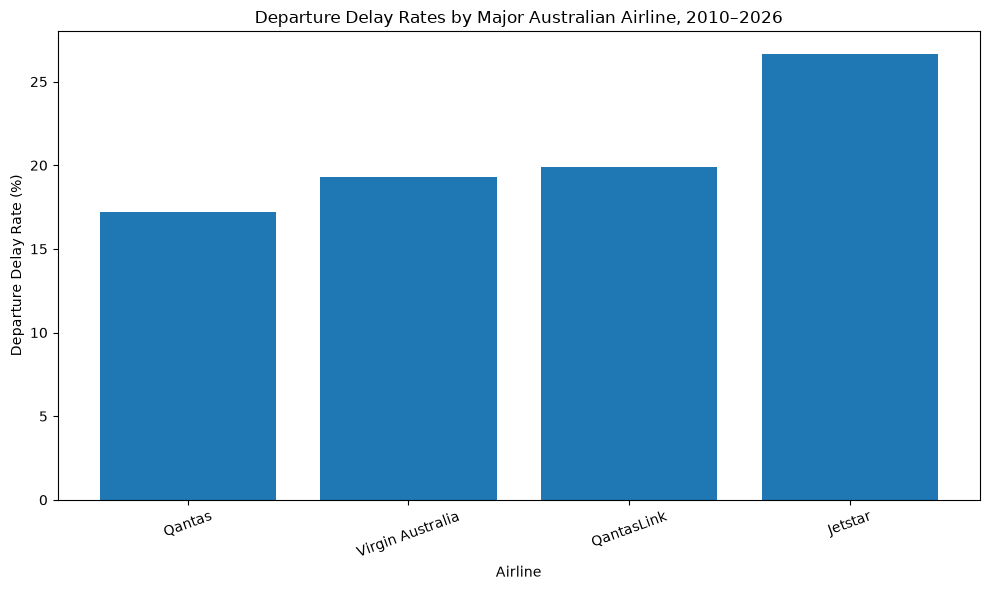

In [16]:
# Plot departure delay rates for airlines with full historical coverage.
plt.figure(figsize=(10, 6))

plt.bar(
    comparable_airlines["airline"],
    comparable_airlines["departure_delay_pct"],
)

plt.title(
    "Departure Delay Rates by Major Australian Airline, 2010–2026"
)
plt.xlabel("Airline")
plt.ylabel("Departure Delay Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [17]:
# Keep observations for airlines with complete historical coverage.
major_airline_df = df[
    df["airline"].isin(full_period_airlines)
].copy()

# Create a year column for airline-level annual analysis.
major_airline_df["year"] = (
    major_airline_df["month"].dt.year
)

# Aggregate flight counts by airline and year.
airline_annual_performance = (
    major_airline_df
    .groupby(
        ["airline", "year"],
        as_index=False,
    )
    .agg(
        sectors_flown=("sectors_flown", "sum"),
        departures_on_time=("departures_on_time", "sum"),
        departures_delayed=("departures_delayed", "sum"),
    )
)

# Calculate annual departure delay rates from flight counts.
airline_annual_performance["departure_delay_pct"] = (
    airline_annual_performance["departures_delayed"]
    / airline_annual_performance["sectors_flown"]
    * 100
)

# Display the first few observations.
airline_annual_performance.head()

,airline,year,sectors_flown,departures_on_time,departures_delayed,departure_delay_pct
0,Jetstar,2010,52021.0,41779.0,10242.0,19.688203
1,Jetstar,2011,57903.0,44169.0,13734.0,23.718978
2,Jetstar,2012,64640.0,48926.0,15714.0,24.310025
3,Jetstar,2013,68357.0,50722.0,17635.0,25.798382
4,Jetstar,2014,73792.0,60363.0,13429.0,18.198450


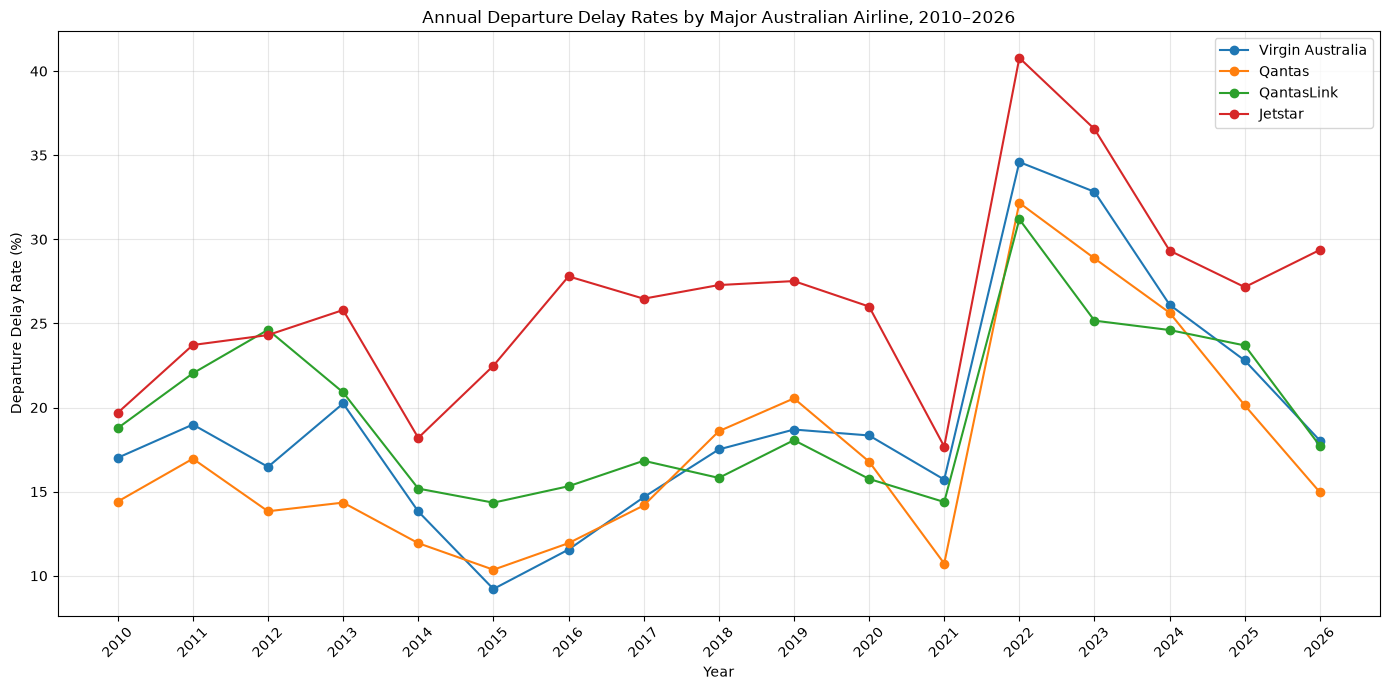

In [18]:
# Plot annual departure delay rates for major airlines.
plt.figure(figsize=(14, 7))

for airline in full_period_airlines:
    airline_data = airline_annual_performance[
        airline_annual_performance["airline"] == airline
    ]

    plt.plot(
        airline_data["year"],
        airline_data["departure_delay_pct"],
        marker="o",
        label=airline,
    )

plt.title(
    "Annual Departure Delay Rates by Major Australian Airline, 2010–2026"
)
plt.xlabel("Year")
plt.ylabel("Departure Delay Rate (%)")
plt.xticks(
    annual_performance["year"],
    rotation=45,
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Aggregate historical flight performance by directional route.
route_performance = (
    df.groupby(
        [
            "route",
            "departing_port",
            "arriving_port",
        ],
        as_index=False,
    )
    .agg(
        sectors_flown=("sectors_flown", "sum"),
        departures_on_time=("departures_on_time", "sum"),
        departures_delayed=("departures_delayed", "sum"),
        cancellations=("cancellations", "sum"),
        sectors_scheduled=("sectors_scheduled", "sum"),
    )
)

# Calculate route-level departure delay rates using
# the underlying flight counts.
route_performance["departure_delay_pct"] = (
    route_performance["departures_delayed"]
    / route_performance["sectors_flown"]
    * 100
)

# Calculate route-level cancellation rates.
route_performance["cancellation_pct"] = (
    route_performance["cancellations"]
    / route_performance["sectors_scheduled"]
    * 100
)

# Select the 30 busiest directional routes
# based on the total number of sectors flown.
busiest_routes = (
    route_performance
    .sort_values(
        "sectors_flown",
        ascending=False,
    )
    .head(30)
    .copy()
)

# Rank the busiest routes by departure delay rate.
busiest_routes_by_delay = busiest_routes.sort_values(
    "departure_delay_pct",
    ascending=False,
)

# Display the route comparison.
busiest_routes_by_delay[
    [
        "route",
        "sectors_flown",
        "departure_delay_pct",
        "cancellation_pct",
    ]
]

,route,sectors_flown,departure_delay_pct,cancellation_pct
67,Gold Coast-Melbourne,90024.0,27.144517,2.867871
74,Hobart-Melbourne,76853.0,27.095364,1.961960
143,Sydney-Perth,69260.0,26.130523,1.287003
96,Melbourne-Perth,81927.0,24.207526,1.842689
92,Melbourne-Hobart,76974.0,23.710448,1.816373
90,Melbourne-Gold Coast,90156.0,23.565353,2.682398
69,Gold Coast-Sydney,128756.0,23.222025,3.081671
117,Perth-Sydney,68320.0,22.925937,1.621404
114,Perth-Melbourne,82231.0,22.190536,2.089634
142,Sydney-Melbourne,379357.0,21.787066,5.782585


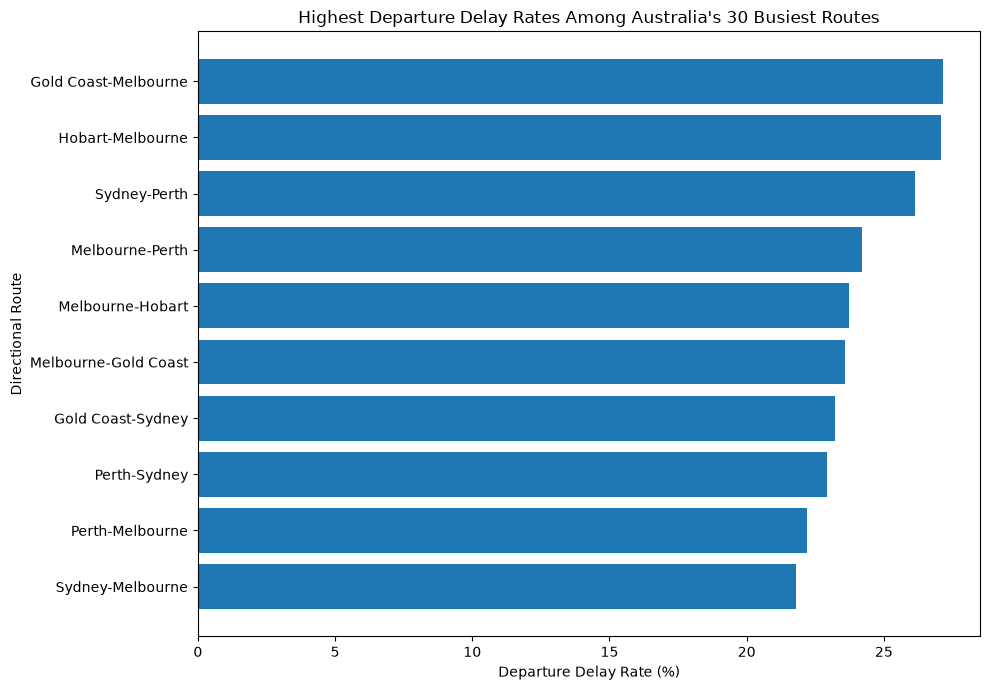

In [20]:
# Select the 10 highest-delay routes among the
# 30 busiest directional routes.
top_delay_routes = (
    busiest_routes_by_delay
    .head(10)
    .sort_values(
        "departure_delay_pct",
        ascending=True,
    )
)

# Plot historical departure delay rates for the selected routes.
plt.figure(figsize=(10, 7))

plt.barh(
    top_delay_routes["route"],
    top_delay_routes["departure_delay_pct"],
)

plt.title(
    "Highest Departure Delay Rates Among Australia's 30 Busiest Routes"
)
plt.xlabel("Departure Delay Rate (%)")
plt.ylabel("Directional Route")
plt.tight_layout()
plt.show()

In [21]:
# Create a month-of-year column for seasonality analysis.
df["month_of_year"] = df["month"].dt.month

# Aggregate flight counts by calendar month.
seasonal_performance = (
    df.groupby(
        "month_of_year",
        as_index=False,
    )
    .agg(
        sectors_flown=("sectors_flown", "sum"),
        departures_on_time=("departures_on_time", "sum"),
        departures_delayed=("departures_delayed", "sum"),
        sectors_scheduled=("sectors_scheduled", "sum"),
        cancellations=("cancellations", "sum"),
    )
)

# Calculate seasonal departure delay rates.
seasonal_performance["departure_delay_pct"] = (
    seasonal_performance["departures_delayed"]
    / seasonal_performance["sectors_flown"]
    * 100
)

# Calculate seasonal cancellation rates.
seasonal_performance["cancellation_pct"] = (
    seasonal_performance["cancellations"]
    / seasonal_performance["sectors_scheduled"]
    * 100
)

# Add readable month names.
month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

seasonal_performance["month_name"] = (
    seasonal_performance["month_of_year"]
    .map(month_names)
)

# Display seasonal performance.
seasonal_performance[
    [
        "month_name",
        "sectors_flown",
        "departure_delay_pct",
        "cancellation_pct",
    ]
]

,month_name,sectors_flown,departure_delay_pct,cancellation_pct
0,Jan,562197.0,18.445136,2.773445
1,Feb,520077.0,17.850049,2.554018
2,Mar,581606.0,19.219197,3.197479
3,Apr,561678.0,18.951962,2.324684
4,May,559762.0,16.987756,2.156103
5,Jun,535548.0,20.216680,3.954290
6,Jul,535966.0,24.254337,4.095352
7,Aug,517976.0,19.351862,2.790310
8,Sep,516733.0,19.669926,2.238514
9,Oct,535520.0,21.154952,2.086906


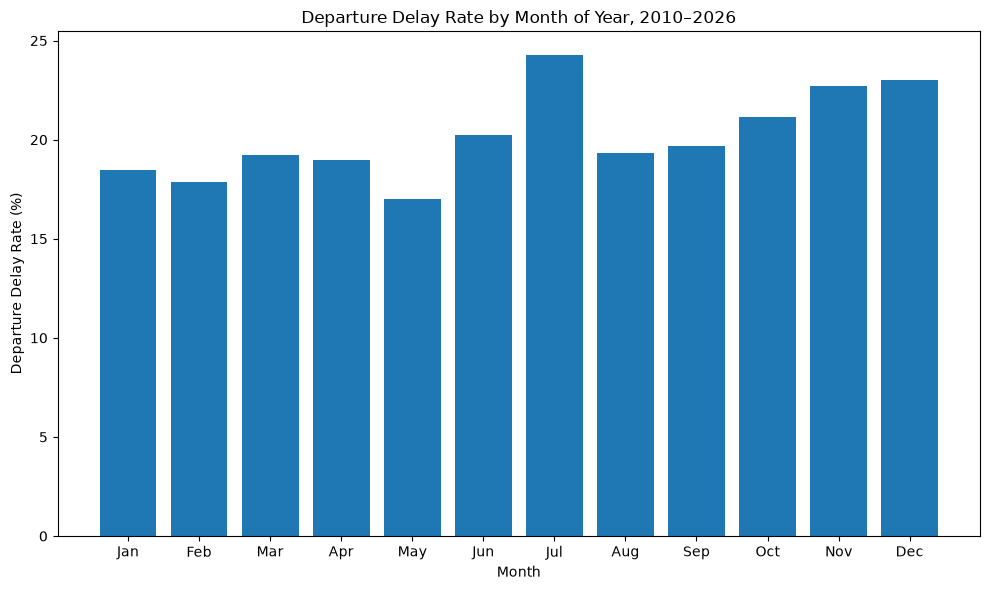

In [22]:
# Plot historical departure delay rates by calendar month.
plt.figure(figsize=(10, 6))

plt.bar(
    seasonal_performance["month_name"],
    seasonal_performance["departure_delay_pct"],
)

plt.title(
    "Departure Delay Rate by Month of Year, 2010–2026"
)
plt.xlabel("Month")
plt.ylabel("Departure Delay Rate (%)")
plt.tight_layout()
plt.show()

In [23]:
# Use complete calendar years only for seasonality comparison.
complete_year_df = df[
    df["month"].dt.year <= 2025
].copy()

# Create year and month-of-year features.
complete_year_df["year"] = complete_year_df["month"].dt.year
complete_year_df["month_of_year"] = complete_year_df["month"].dt.month

# Aggregate flight counts for each year and calendar month.
year_month_performance = (
    complete_year_df
    .groupby(
        ["year", "month_of_year"],
        as_index=False,
    )
    .agg(
        sectors_flown=("sectors_flown", "sum"),
        departures_delayed=("departures_delayed", "sum"),
    )
)

# Calculate the delay rate for each individual year-month.
year_month_performance["departure_delay_pct"] = (
    year_month_performance["departures_delayed"]
    / year_month_performance["sectors_flown"]
    * 100
)

# Summarise how each calendar month performs across years.
seasonality_summary = (
    year_month_performance
    .groupby(
        "month_of_year",
        as_index=False,
    )
    .agg(
        mean_delay_pct=("departure_delay_pct", "mean"),
        median_delay_pct=("departure_delay_pct", "median"),
        min_delay_pct=("departure_delay_pct", "min"),
        max_delay_pct=("departure_delay_pct", "max"),
    )
)

# Add readable month names.
seasonality_summary["month_name"] = (
    seasonality_summary["month_of_year"]
    .map(month_names)
)

# Display the seasonal summary.
seasonality_summary[
    [
        "month_name",
        "mean_delay_pct",
        "median_delay_pct",
        "min_delay_pct",
        "max_delay_pct",
    ]
]

,month_name,mean_delay_pct,median_delay_pct,min_delay_pct,max_delay_pct
0,Jan,17.967564,16.111960,11.215455,27.227073
1,Feb,17.579660,16.527903,9.609642,26.430243
2,Mar,18.985829,20.084155,11.136577,29.452642
3,Apr,18.563109,17.306712,9.100999,39.539245
4,May,16.610699,15.420286,9.467865,37.111431
5,Jun,19.972564,18.565186,10.963794,40.261961
6,Jul,23.595993,21.528690,11.773882,48.690293
7,Aug,18.843412,16.714916,9.710149,33.095943
8,Sep,18.891990,17.857848,8.849244,33.780009
9,Oct,20.352082,20.590335,10.552229,32.832605


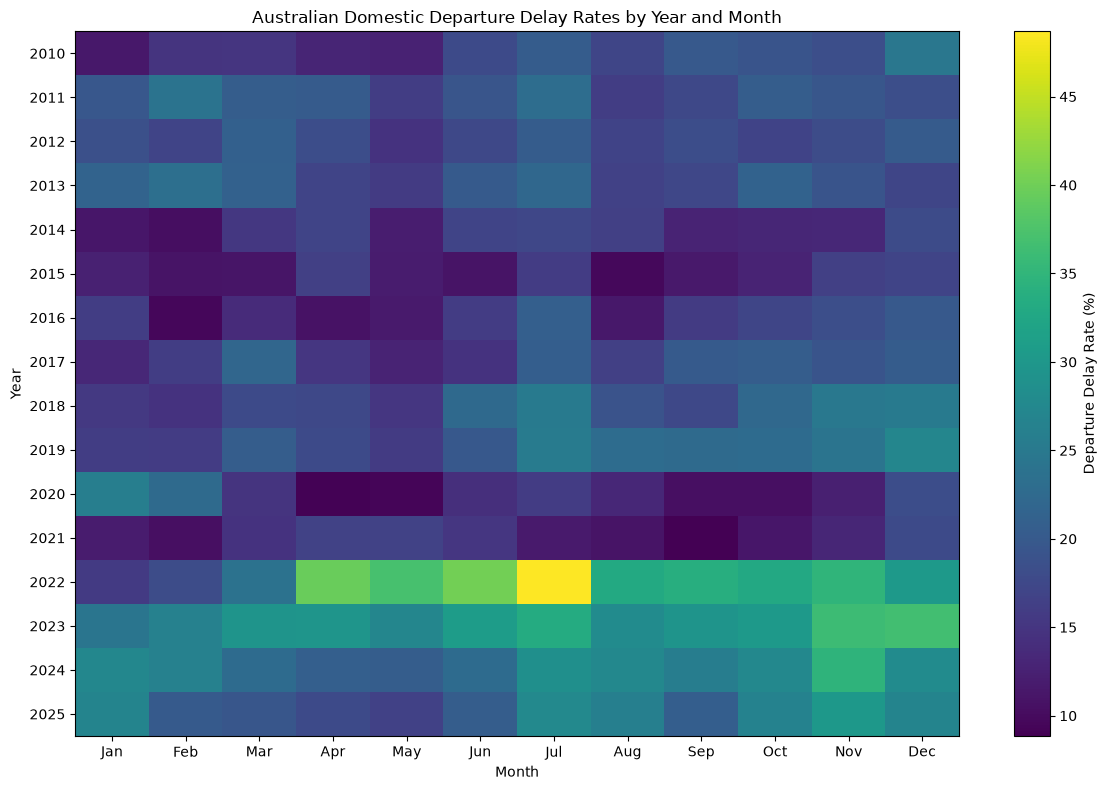

In [24]:
# Reshape yearly monthly delay rates into a matrix
# for visual comparison across years and months.
delay_heatmap = year_month_performance.pivot(
    index="year",
    columns="month_of_year",
    values="departure_delay_pct",
)

# Plot departure delay rates across years and calendar months.
plt.figure(figsize=(12, 8))

heatmap = plt.imshow(
    delay_heatmap,
    aspect="auto",
)

# Add a colour scale showing the departure delay rate.
plt.colorbar(
    heatmap,
    label="Departure Delay Rate (%)",
)

# Add readable month labels.
plt.xticks(
    range(12),
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
)

# Add year labels.
plt.yticks(
    range(len(delay_heatmap.index)),
    delay_heatmap.index,
)

plt.title(
    "Australian Domestic Departure Delay Rates by Year and Month"
)
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [25]:
# Create a route-airline-month departure delay rate
# for observations where at least one sector was flown.
model_eda_df = df[
    df["sectors_flown"] > 0
].copy()

model_eda_df["departure_delay_pct"] = (
    model_eda_df["departures_delayed"]
    / model_eda_df["sectors_flown"]
    * 100
)

# Display summary statistics for the potential target.
print("Departure delay percentage distribution:")
print("----------------------------------------")
print(
    model_eda_df["departure_delay_pct"].describe()
)

# Display the number of observations available for modelling.
print(
    f"\nPotential modelling observations: "
    f"{len(model_eda_df)}"
)

Departure delay percentage distribution:
----------------------------------------
count    69074.000000
mean        20.440600
std         13.995479
min          0.000000
25%         10.389610
50%         17.775932
75%         27.534765
max        100.000000
Name: departure_delay_pct, dtype: float64

Potential modelling observations: 69074


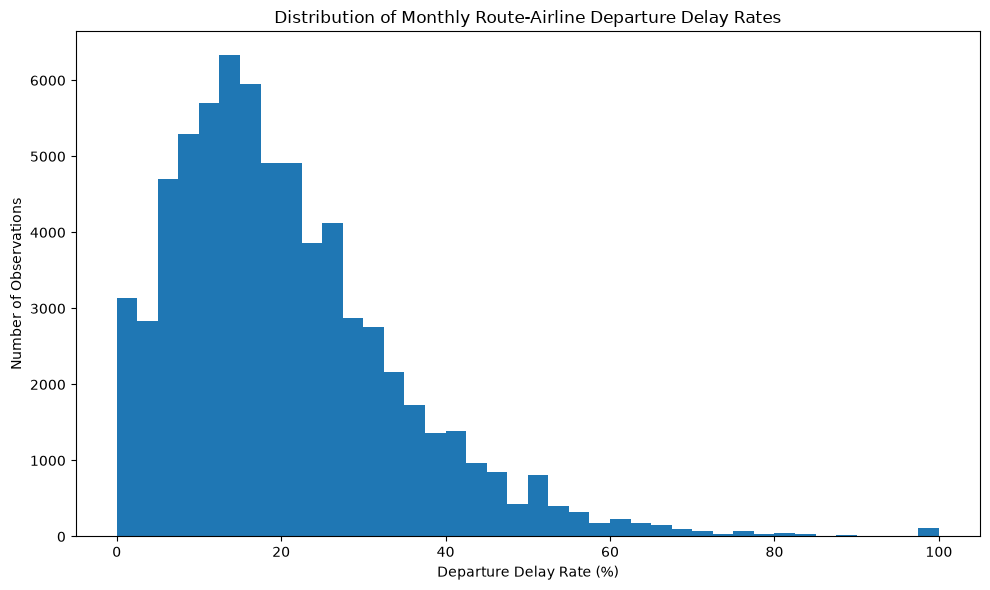

In [26]:
# Plot the distribution of route-airline-month
# departure delay percentages.
plt.figure(figsize=(10, 6))

plt.hist(
    model_eda_df["departure_delay_pct"],
    bins=40,
)

plt.title(
    "Distribution of Monthly Route-Airline Departure Delay Rates"
)
plt.xlabel("Departure Delay Rate (%)")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

In [27]:
# Create flight-volume bands to investigate the stability
# of monthly route-airline departure delay rates.
volume_bins = [
    0,
    10,
    25,
    50,
    100,
    250,
    500,
    float("inf"),
]

volume_labels = [
    "1–10",
    "11–25",
    "26–50",
    "51–100",
    "101–250",
    "251–500",
    "500+",
]

model_eda_df["flight_volume_band"] = pd.cut(
    model_eda_df["sectors_flown"],
    bins=volume_bins,
    labels=volume_labels,
    include_lowest=True,
)

# Summarise the target distribution within each
# monthly flight-volume band.
volume_target_summary = (
    model_eda_df
    .groupby(
        "flight_volume_band",
        observed=True,
    )
    .agg(
        observations=("departure_delay_pct", "size"),
        median_sectors_flown=("sectors_flown", "median"),
        mean_delay_pct=("departure_delay_pct", "mean"),
        median_delay_pct=("departure_delay_pct", "median"),
        std_delay_pct=("departure_delay_pct", "std"),
        min_delay_pct=("departure_delay_pct", "min"),
        max_delay_pct=("departure_delay_pct", "max"),
    )
    .reset_index()
)

volume_target_summary

,flight_volume_band,observations,median_sectors_flown,mean_delay_pct,median_delay_pct,std_delay_pct,min_delay_pct,max_delay_pct
0,1–10,2768,6.0,21.532179,12.500000,25.397916,0.000000,100.000000
1,11–25,8734,18.0,20.932172,16.666667,17.444792,0.000000,100.000000
2,26–50,19134,31.0,20.518653,17.021277,14.867082,0.000000,97.368421
3,51–100,16428,74.0,20.178021,17.977528,12.046908,0.000000,83.606557
4,101–250,17767,134.0,20.326724,18.518519,10.808187,0.000000,77.443609
5,251–500,3010,324.0,20.511634,18.982290,9.940956,2.956989,60.493827
6,500+,1233,678.0,18.262765,16.603295,8.480458,2.926209,63.255814


In [28]:
# Compare candidate minimum flight-volume thresholds
# before creating the modelling dataset.
thresholds = [
    1,
    10,
    25,
    50,
    100,
]

threshold_results = []

# Calculate dataset size and target variability
# for each candidate threshold.
for threshold in thresholds:
    threshold_df = model_eda_df[
        model_eda_df["sectors_flown"] >= threshold
    ]

    threshold_results.append(
        {
            "minimum_sectors_flown": threshold,
            "observations": len(threshold_df),
            "data_retained_pct": (
                len(threshold_df)
                / len(model_eda_df)
                * 100
            ),
            "mean_delay_pct": (
                threshold_df["departure_delay_pct"].mean()
            ),
            "median_delay_pct": (
                threshold_df["departure_delay_pct"].median()
            ),
            "std_delay_pct": (
                threshold_df["departure_delay_pct"].std()
            ),
        }
    )

# Convert the threshold comparison into a DataFrame.
threshold_comparison = pd.DataFrame(
    threshold_results
)

threshold_comparison

,minimum_sectors_flown,observations,data_retained_pct,mean_delay_pct,median_delay_pct,std_delay_pct
0,1,69074,100.000000,20.440600,17.775932,13.995479
1,10,66578,96.386484,20.402880,17.857143,13.338399
2,25,58282,84.376176,20.322541,17.941522,12.617356
3,50,38795,56.164403,20.212436,18.260870,11.262177
4,100,22295,32.276978,20.238525,18.454936,10.591445


## EDA Summary

The historical BITRE route-level dataset contains monthly airline performance data from January 2010 to June 2026.

Key findings:

- Australian domestic departure performance was relatively stable before 2020, followed by major disruption during the COVID-19 period.
- Departure delays increased substantially in 2022, with July 2022 recording the highest monthly delay rate in the dataset.
- Performance improved gradually from 2023 onward.
- Qantas had the lowest historical departure delay rate among the four major airlines with complete 2010–2026 coverage, while Jetstar had the highest.
- Delay rates vary by directional route, supporting the use of route and departure/arrival locations as potential model features.
- Calendar month shows a seasonal relationship with delay rates, with July having the highest median delay rate across complete years.
- Monthly route-airline delay rates become substantially more volatile when only a small number of flights are operated.
- A minimum threshold of 25 sectors flown per route-airline-month retains approximately 84% of usable observations while reducing instability in the modelling target.

Based on these findings, departure delay percentage will be used as the initial regression target, with observations containing at least 25 flown sectors retained for modelling.